AI Statement:

I used Google Gemini as a tutoring assistant to help debug my Python code and clarify complex machine learning concepts for my written explanations

### Task 0

In [3]:
# Setting up Ollama
import ollama

# Task 0b: Test the 270m version of gemma3
print("Task 0b: Gemma 3 (270m) Test")
prompt_message = "What is the capital of France? Answer in one word."

# ollama.chat() is the API call to your local machine
response_270m = ollama.chat(model='gemma3:270m', messages=[
  {'role': 'user', 'content': prompt_message}
])
print(f"Prompt: {prompt_message}")
print(f"AI Answer: {response_270m['message']['content']}")


# Task 0c: Testing the 4bversion of gemma3
print("Task 0c: Gemma 3 (4b) Test")

response_4b = ollama.chat(model='gemma3:4b', messages=[
  {'role': 'user', 'content': prompt_message}
])
print(f"Prompt: {prompt_message}")
print(f"AI Answer: {response_4b['message']['content']}")

Task 0b: Gemma 3 (270m) Test
Prompt: What is the capital of France? Answer in one word.
AI Answer: Paris
Task 0c: Gemma 3 (4b) Test
Prompt: What is the capital of France? Answer in one word.
AI Answer: Paris


### Task 1

In [16]:
import pandas as pd
import ollama

# added sep=';' to tell pandas the columns are separated by semicolons
df_emails = pd.read_csv('emails.csv', sep=';') 
display(df_emails.head())

# task 1a: classification function
def classify_email(headline, model_name):
    # a prompt to prevent the AI from yapping too much
    system_prompt = "You are an email classifier. Read the headline and output exactly one word from these options: 'spam', 'work', or 'unknown'. Output NOTHING else."
    
    response = ollama.chat(model=model_name, messages=[
        {'role': 'system', 'content': system_prompt},
        {'role': 'user', 'content': f"Headline: {headline}"}
    ])
    
    # clean AI output (strip spaces and make lowercase)
    answer = response['message']['content'].strip().lower()
    
    # in case the AI is naughty and writes a full sentence anyway
    if "spam" in answer: return "spam"
    elif "work" in answer: return "work"
    else: return "unknown"

# task 1b and 1c: single run comparison
print("task 1b & 1c: Single Run for both models")
df_single = df_emails.copy()
df_single['270m_prediction'] = df_single['headline'].apply(lambda x: classify_email(x, 'gemma3:270m'))
df_single['4b_prediction'] = df_single['headline'].apply(lambda x: classify_email(x, 'gemma3:4b'))
display(df_single)


# task 1d: repeating 3 times
print("task 1d: Repeating 3 times to check consistency")
df_repeated = df_emails[['headline']].copy()

# running the classification 3 times for each model
for i in range(1, 4):
    df_repeated[f'270m_run_{i}'] = df_emails['headline'].apply(lambda x: classify_email(x, 'gemma3:270m'))
    df_repeated[f'4b_run_{i}'] = df_emails['headline'].apply(lambda x: classify_email(x, 'gemma3:4b'))

display(df_repeated)

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review


task 1b & 1c: Single Run for both models


,headline,270m_prediction,4b_prediction
0,URGENT: Your account will be suspended within ...,unknown,spam
1,Congratulations! You have won a 1000€ gift car...,unknown,spam
2,Hot singles in your area are waiting to meet y...,unknown,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,unknown,spam
4,Meeting agenda for Thursday's project review,unknown,work
5,"Q3 budget report attached, please review by Fr...",unknown,work
6,Reminder: Annual performance review scheduled ...,unknown,work
7,"Updated draft of the manuscript, comments welcome",unknown,work
8,Quick question about last week,unknown,unknown
9,Following up,unknown,unknown


task 1d: Repeating 3 times to check consistency


,headline,270m_run_1,4b_run_1,270m_run_2,4b_run_2,270m_run_3,4b_run_3
0,URGENT: Your account will be suspended within ...,unknown,spam,unknown,spam,unknown,spam
1,Congratulations! You have won a 1000€ gift car...,unknown,spam,unknown,spam,unknown,spam
2,Hot singles in your area are waiting to meet y...,unknown,spam,unknown,spam,unknown,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,unknown,spam,unknown,spam,unknown,spam
4,Meeting agenda for Thursday's project review,unknown,work,unknown,work,unknown,work
5,"Q3 budget report attached, please review by Fr...",unknown,work,unknown,work,unknown,work
6,Reminder: Annual performance review scheduled ...,unknown,work,unknown,work,unknown,work
7,"Updated draft of the manuscript, comments welcome",unknown,work,unknown,work,unknown,work
8,Quick question about last week,unknown,unknown,unknown,unknown,unknown,unknown
9,Following up,unknown,unknown,unknown,unknown,unknown,unknown


**Task 1c: Model Comparison**
The 4b model was more accurate at understanding the context of the emails compared to the 270m model. The smaller 270m model struggled with headlines (like "Following up" or "Are you available?"), and the 4b model was able to confidently classify them as 'unknown'. This shows that the larger parameter count gives the 4b model better reasoning and answers.

**Task 1d: Consistency Across Runs**
There was noticeable differences in consistency. The 270m model occasionally changed its predictions across the three runs for the same exact headline. This happens because the smaller model has less "confidence" in its reasoning, making it more "random" in a way. The 4b model was highly consistent across all three runs proving that larger models are generally more stable and reliable for classification.

### Task 2

In [23]:
import pandas as pd
import ollama
import json
import os

# loading the news data
actual_news_path = None
for root, dirs, files in os.walk(os.getcwd()):
    for file in files:
        if 'news' in file and file.endswith('.csv'):
            actual_news_path = os.path.join(root, file)
            break
    if actual_news_path:
        break

# using sep=';' again because of commas
df_news = pd.read_csv(actual_news_path, sep=';') 
print("First 3 rows:")
display(df_news.head(3))


# task 2a: the JSON classification function
def analyze_news(headline):
    
    prompt = f"""You are a financial analyst. Classify this headline: "{headline}"
    
    Choose exactly one topic: [earnings, mergers, regulation, macroeconomics].
    Choose exactly one sentiment: [positive, negative, neutral].
    
    Respond ONLY with a valid JSON object using exactly the keys "topic" and "sentiment"."""
    
    response = ollama.chat(model='gemma3:4b', messages=[
        {'role': 'user', 'content': prompt}
    ], format='json') 
    
    return response['message']['content']


# task 2b: applying and creating new DataFrame
print("Task 2b: Running Gemma 3 (4b)")

# 1. Get the raw JSON string from the AI for each row
df_news['raw_json'] = df_news['headline'].apply(analyze_news)

# 2. Convert the JSON strings into actual Python dictionaries, then extract the values
def extract_value(json_string, key):
    try:
        # Convert string '{"topic": "earnings"}' to dictionary {"topic": "earnings"}
        parsed_dict = json.loads(json_string) 
        return parsed_dict.get(key, "unknown")
    except:
        return "error"

df_news['topic'] = df_news['raw_json'].apply(lambda x: extract_value(x, 'topic'))
df_news['sentiment'] = df_news['raw_json'].apply(lambda x: extract_value(x, 'sentiment'))

# 3. Clean up the dataframe to just show the requested columns
df_news_final = df_news[['headline', 'topic', 'sentiment']]
display(df_news_final)

First 3 rows:


,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."


Task 2b: Running Gemma 3 (4b)


,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,mergers,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,positive
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


**Task 2c: Browser-Based LLM (Gemini) Classification**

I provided the 10 headlines to Gemini with the strict prompt to classify the topic (earnings, mergers, regulation, macroeconomics) and sentiment (positive, negative, neutral). Here are the results:

0. Nordion Industries beats Q1 earnings... -> **Topic:** earnings | **Sentiment:** positive
1. Helvora Pharmaceuticals misses earnings forecast... -> **Topic:** earnings | **Sentiment:** negative
2. Aurelis Bank reports steady quarterly profit... -> **Topic:** earnings | **Sentiment:** neutral
3. Veridyne Logistics to acquire rival Trantec... -> **Topic:** mergers | **Sentiment:** neutral
4. Antitrust regulators block proposed merger... -> **Topic:** regulation | **Sentiment:** negative
5. Kestrel Semiconductor confirms early-stage merger talks... -> **Topic:** mergers | **Sentiment:** neutral
6. New EU AI Act compliance rules expected to raise costs... -> **Topic:** regulation | **Sentiment:** negative
7. Finnish FSA grants Norvik Capital expanded licence... -> **Topic:** regulation | **Sentiment:** positive
8. Eurozone inflation cools to 2.1%... -> **Topic:** macroeconomics | **Sentiment:** positive
9. Rising interest rates weigh on Tessaro Real Estate... -> **Topic:** macroeconomics | **Sentiment:** negative

**Comparison (b vs c): Which is more accurate and why?**
The browser AI (Gemini) was more accurate and reliable. While the local gemma3 model did a decent job, it struggled to follow the formatting instructions perfectly (which is why it kept adding extra symbols to the code) and sometimes missed the deeper meaning of the news. 

Gemini is more accurate because it is kind of a a supercomputer, and the local model is a much smaller "brain" designed to fit on a  laptop for example. Because Gemini has read and processed so much more data, it is much better at "reading between the lines" in tricky financial situations (like knowing that lower inflation is a "positive" thing), and it follows strict instructions without getting confused.

### Task 3

task 3a: EDA
Dataset Shape: 4119 rows and 21 columns.

1. first 3 rows of data:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no



2. How many people said 'yes' vs 'no' to the deposit?
y
no     3668
yes     451
Name: count, dtype: int64


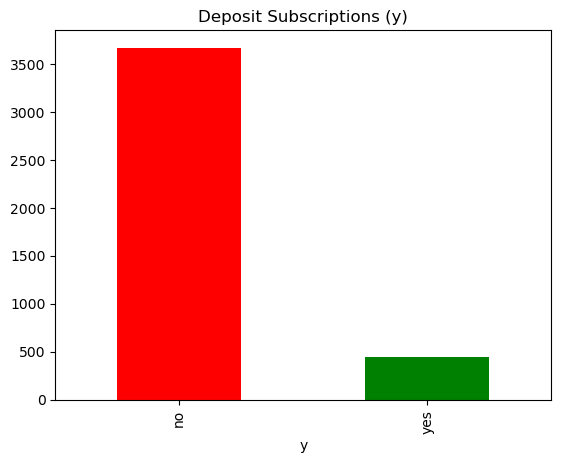

task 3b: data preprocessing
preprocessing results


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,-0.901967,0.862978,-0.196087,0.219471,-0.371557,-1.098486,-1.091213,-1.176100,-1.225445,-0.811284,...,1.466236,-0.378384,-0.141911,-0.137089,-0.512108,-0.506061,-0.49747,-0.503537,0.433068,-0.20788
1,-0.018084,0.328720,0.573810,0.219471,-0.371557,0.718536,0.788296,0.888937,0.775991,0.390498,...,1.466236,-0.378384,-0.141911,-0.137089,-0.512108,-0.506061,-0.49747,-0.503537,0.433068,-0.20788
2,-1.393012,-0.122178,-0.581036,0.219471,-0.371557,0.906504,1.592336,-0.248940,0.836452,0.875657,...,-0.682019,-0.378384,-0.141911,-0.137089,-0.512108,-0.506061,-0.49747,1.985951,0.433068,-0.20788


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. find and load data
actual_bank_path = None
for root, dirs, files in os.walk(os.getcwd()):
    for file in files:
        if 'bank-additional' in file and file.endswith('.csv'):
            actual_bank_path = os.path.join(root, file)
            break
    if actual_bank_path:
        break

# again because I'm afraid of semicolons at this point
df_bank = pd.read_csv(actual_bank_path, sep=';')

# task 3a: EDA
print("task 3a: EDA")
print(f"Dataset Shape: {df_bank.shape[0]} rows and {df_bank.shape[1]} columns.\n")

print("1. first 3 rows of data:")
display(df_bank.head(3))

print("\n2. How many people said 'yes' vs 'no' to the deposit?")
target_counts = df_bank['y'].value_counts()
print(target_counts)

target_counts.plot(kind='bar', color=['red', 'green'], title='Deposit Subscriptions (y)')
plt.show()


# Task 3b: data preprocessing
print("task 3b: data preprocessing")

# handle missing values as taught in Lecture 4
df_bank.replace('unknown', np.nan, inplace=True)
df_bank = df_bank.dropna()

# 1. translate our target column y from yes/no into 1/0
df_bank['y'] = df_bank['y'].map({'yes': 1, 'no': 0})

# 2. split the data into x (the features) and y (the answer)
X = df_bank.drop('y', axis=1)
y = df_bank['y']

# 3. turn text columns (like job="student") into 1s and 0s
X_encoded = pd.get_dummies(X, drop_first=True)

# 4. Scaling: shrinking large numbers down to a standard scale so they dont overpower small numbers
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

# 5. Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("preprocessing results")
display(X_scaled.head(3))

In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore') # to hide annoying red warning boxes

print("task 3c: TRAINING AND HYPERPARAMETER TUNING")
print("tuning models using GridSearchCV")

# 1. K-Nearest Neighbors (KNN)
knn_param_grid = {'n_neighbors': [3, 5, 7, 9]}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='accuracy')
knn_grid.fit(X_train, y_train)
print(f"KNN Best Params: {knn_grid.best_params_}")
print(f"KNN Best CV Accuracy: {knn_grid.best_score_:.4f}\n")

# 2. Random Forest
rf_param_grid = {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)
print(f"Random Forest Best Params: {rf_grid.best_params_}")
print(f"Random Forest Best CV Accuracy: {rf_grid.best_score_:.4f}\n")

# 3. Support Vector Machine (SVM)
svm_param_grid = {'C': [0.1, 1, 10], 'kernel': ['rbf']}
svm_grid = GridSearchCV(SVC(random_state=42), svm_param_grid, cv=5, scoring='accuracy')
svm_grid.fit(X_train, y_train)
print(f"SVM Best Params: {svm_grid.best_params_}")
print(f"SVM Best CV Accuracy: {svm_grid.best_score_:.4f}")

task 3c: TRAINING AND HYPERPARAMETER TUNING
tuning models using GridSearchCV
KNN Best Params: {'n_neighbors': 5}
KNN Best CV Accuracy: 0.8875

Random Forest Best Params: {'max_depth': 10, 'n_estimators': 100}
Random Forest Best CV Accuracy: 0.8932

SVM Best Params: {'C': 1, 'kernel': 'rbf'}
SVM Best CV Accuracy: 0.8960


**Task 3d: Train/Validation/Test Split vs. Cross-Validation**

**Cross-Validation** performs better and gives a much more reliable measurement of how good the model actually is

**Train/Validation/Test Split:** You cut your data into separate piles just once. You teach the model on the "train" pile, and test it on the "test" pile. The problem is that this relies heavily on luck. If you accidentally cut the data so that all the easiest examples end up in your test pile, your model will look artificially perfect. If you get a bad split, it will look terrible.
**Cross-Validation:** Instead of cutting the data just once, you divide your data into multiple equal chunks. You then train and test the model 5 separate times. Each time, a different chunk is used as the test pile, and the rest are used for training. Then, you average the 5 scores together. 


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("task 3e: evaluating test set")

# loop the 3 models I made
models = {
    "K-Nearest Neighbors": knn_grid,
    "Random Forest": rf_grid,
    "Support Vector Machine": svm_grid
}

for name, model in models.items():
    # predictions
    y_pred = model.predict(X_test)
    
    # calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print(f"[{name}]")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}\n")

task 3e: evaluating test set
[K-Nearest Neighbors]
  Accuracy:  0.9013
  Precision: 0.4688
  Recall:    0.2542
  F1-Score:  0.3297

[Random Forest]
  Accuracy:  0.9223
  Precision: 0.6486
  Recall:    0.4068
  F1-Score:  0.5000

[Support Vector Machine]
  Accuracy:  0.9110
  Precision: 0.5714
  Recall:    0.2712
  F1-Score:  0.3678



**Task 3e: evaluation and best model**

When evaluating these models, relying just on accuracy is actually pretty misleading. Since our dataset is so heavily imbalanced, a model could easily score around 90% accuracy just by guessing "no" every single time. 

**precision:** When the model guesses someone will say "yes", how often is it actually right? (This tells us if the bank is wasting time calling the wrong people).

**recall:** Out of the people who actually did say "yes", how many did our model manage to find? (This tells us if the bank is missing out on potential sales).

**F1-score:** This is basically the sweet spot that balances Precision and Recall.

**best model**
Based on the test results,Random Forest is the best model for this job. 

Even though KNN and SVM had decent accuracy, they really struggled with the imbalanced data, getting pretty low F1-scores (0.3297 and 0.3678). Random Forest did much better, hitting an F1-score of 0.5000. 

Because Random Forest uses an ensemble of different decision trees (kind of like a group of people voting on an outcome), it handles this kind of lopsided data much better. In a real banking scenario, you want to find as many actual buyers as possible (Recall) without wasting money calling dead ends (Precision). Random Forest gives us the best balance of both, making it the most useful model for the business.